In [1]:
import pandas as pd
import numpy as np 
import os
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

In [2]:
INPUT_PATH = "https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz"
OUTPUT_PATH = '../data/openfoodfacts_regression_clean.csv'
 
# Colonnes pour les features et la cible numérique
nutriscore_cols = [
    'energy_100g', 'fat_100g', 'saturated-fat_100g',
    'sugars_100g', 'fiber_100g', 'proteins_100g', 'carbohydrates_100g',
    'salt_100g'
]
 
# Changement : on vise le SCORE (numérique)
target = 'nutriscore_score'
identity_cols = ['code', 'product_name', 'nutriscore_grade'] # On garde le grade juste pour info
 
cols = nutriscore_cols + [target] + identity_cols
def process_data(file_path, cols, chunk_size=20000):
    reader = pd.read_csv(
        file_path, compression='gzip', sep='\t',
        on_bad_lines='skip', chunksize=chunk_size,
        low_memory=False, usecols=cols
    )
 
    clean_chunks = []
    print("Lecture des blocs...")
    
    for i, chunk in enumerate(reader):
 
        temp_chunk = chunk.copy()
 
        # 1. Nettoyage de la Cible (Target)
        # On supprime les lignes où le score numérique manque
        temp_chunk = temp_chunk.dropna(subset=[target])
        cols_to_convert = nutriscore_cols + [target]
 
        # 2. Conversion numérique des nutriments
        for col in cols_to_convert:
            temp_chunk[col] = pd.to_numeric(temp_chunk[col], errors='coerce')
 
        # Filtre de réalisme pour le score (Officiel : -15 à +40)
        temp_chunk = temp_chunk[(temp_chunk[target] >= -15) & (temp_chunk[target] <= 40)]            
 
        # Remplissage des nutriments manquants par 0 (Imputation)
        temp_chunk[nutriscore_cols] = temp_chunk[nutriscore_cols].fillna(0)
        
        # 3. Filtres Outliers (0-100g et Energie)
        for col in nutriscore_cols:
            if col != 'energy_100g':
                temp_chunk = temp_chunk[(temp_chunk[col] >= 0) & (temp_chunk[col] <= 100)]
        
        temp_chunk = temp_chunk[(temp_chunk['energy_100g'] >= 0) & (temp_chunk['energy_100g'] < 4000)]
 
        # 4. Gestion de l'identité
        temp_chunk['product_name'] = temp_chunk['product_name'].fillna('Unknown Product')
        temp_chunk = temp_chunk.drop_duplicates(subset=['code'])
 
         # 5. Stockage du bloc propre
        if not temp_chunk.empty:
            clean_chunks.append(temp_chunk)
        
        if i % 10 == 0:
            print(f"Bloc {i} chargé...")
    
    print("Fusion de tous les blocs...")
    df_final = pd.concat(clean_chunks, ignore_index=True)
    
    return df_final
 
 
# Lancement
df_raw = process_data(INPUT_PATH, cols)

Lecture des blocs...
Bloc 0 chargé...
Bloc 10 chargé...
Bloc 20 chargé...
Bloc 30 chargé...
Bloc 40 chargé...
Bloc 50 chargé...
Bloc 60 chargé...
Bloc 70 chargé...
Bloc 80 chargé...
Bloc 90 chargé...
Bloc 100 chargé...
Bloc 110 chargé...
Bloc 120 chargé...
Bloc 130 chargé...
Bloc 140 chargé...
Bloc 150 chargé...
Bloc 160 chargé...
Bloc 170 chargé...
Bloc 180 chargé...
Bloc 190 chargé...
Bloc 200 chargé...
Bloc 210 chargé...
Bloc 220 chargé...
Fusion de tous les blocs...


In [3]:
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
df_raw.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')

print(f"Fichier sauvegardé ici : {OUTPUT_PATH}")

Fichier sauvegardé ici : ../data/openfoodfacts_regression_clean.csv


In [4]:
# Copie de travail
df = df_raw.copy()

print("Shape initiale :", df.shape)
print("\nTypes :")
display(df.dtypes)

print("\nValeurs manquantes :")
display(df.isna().sum().sort_values(ascending=False))

Shape initiale : (1351783, 12)

Types :


code                   object
product_name           object
nutriscore_score      float64
nutriscore_grade       object
energy_100g           float64
fat_100g              float64
saturated-fat_100g    float64
carbohydrates_100g    float64
sugars_100g           float64
fiber_100g            float64
proteins_100g         float64
salt_100g             float64
dtype: object


Valeurs manquantes :


code                  0
product_name          0
nutriscore_score      0
nutriscore_grade      0
energy_100g           0
fat_100g              0
saturated-fat_100g    0
carbohydrates_100g    0
sugars_100g           0
fiber_100g            0
proteins_100g         0
salt_100g             0
dtype: int64

In [5]:
# Colonnes utiles
feature_cols = nutriscore_cols.copy()
id_cols = ['code', 'product_name', 'nutriscore_grade']
target_col = target

# Suppression des doublons globaux sur le code
df = df.drop_duplicates(subset=['code']).copy()

# On garde uniquement les lignes avec une cible connue
df = df[df[target_col].notna()].copy()

# Conversion de sécurité
for col in feature_cols + [target_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Imputation simple sur les colonnes nutritionnelles
df[feature_cols] = df[feature_cols].fillna(0)

# Suppression des lignes aberrantes sur la cible
df = df[df[target_col].between(-15, 40)].copy()

print("Shape après nettoyage :", df.shape)
df.head()

Shape après nettoyage : (1351783, 12)


,code,product_name,nutriscore_score,nutriscore_grade,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g
0,7,granola Bio le Chocolaté,4.0,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,8,Unknown Product,6.0,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,9,xytitol pastilles,-11.0,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,13,Powdered peanut butter,3.0,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,15,Madeleines ChocoLait,20.0,e,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Nombre de nutriments non nuls par ligne
df['non_zero_features'] = (df[feature_cols] > 0).sum(axis=1)

# Option: on enlève les lignes sans aucune vraie info nutritionnelle
df = df[df['non_zero_features'] > 0].copy()

print("Shape après retrait des lignes sans info nutritionnelle :", df.shape)
df[['non_zero_features'] + feature_cols].head()

Shape après retrait des lignes sans info nutritionnelle : (277964, 13)


,non_zero_features,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,carbohydrates_100g,salt_100g
86,7,1928.500000,28.000000,13.8,18.0,0.0,6.000000,46.5,0.649
97,3,1357.900028,36.700001,12.7,0.0,0.0,0.000000,0.0,0.000
98,7,1771.899957,35.299999,12.2,4.1,0.0,22.299999,5.1,3.900
116,8,109.600000,0.400000,0.2,1.7,0.8,0.700000,4.5,0.700
117,8,143.000000,0.800000,0.4,2.3,1.1,0.700000,5.5,0.760


In [7]:
# Variables dérivées
df['total_macro_100g'] = (
    df['fat_100g'] +
    df['carbohydrates_100g'] +
    df['proteins_100g'] +
    df['fiber_100g']
)

df['sugar_to_carb_ratio'] = np.where(
    df['carbohydrates_100g'] > 0,
    df['sugars_100g'] / df['carbohydrates_100g'],
    0
)

df['satfat_to_fat_ratio'] = np.where(
    df['fat_100g'] > 0,
    df['saturated-fat_100g'] / df['fat_100g'],
    0
)

df['protein_to_energy_ratio'] = np.where(
    df['energy_100g'] > 0,
    df['proteins_100g'] / df['energy_100g'],
    0
)

df['fiber_to_carb_ratio'] = np.where(
    df['carbohydrates_100g'] > 0,
    df['fiber_100g'] / df['carbohydrates_100g'],
    0
)

derived_cols = [
    'non_zero_features',
    'total_macro_100g',
    'sugar_to_carb_ratio',
    'satfat_to_fat_ratio',
    'protein_to_energy_ratio',
    'fiber_to_carb_ratio'
]

all_features = feature_cols + derived_cols

print("Nombre total de features :", len(all_features))
df[all_features + [target_col]].head()

Nombre total de features : 14


,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,carbohydrates_100g,salt_100g,non_zero_features,total_macro_100g,sugar_to_carb_ratio,satfat_to_fat_ratio,protein_to_energy_ratio,fiber_to_carb_ratio,nutriscore_score
86,1928.500000,28.000000,13.8,18.0,0.0,6.000000,46.5,0.649,7,80.500000,0.387097,0.492857,0.003111,0.000000,23.0
97,1357.900028,36.700001,12.7,0.0,0.0,0.000000,0.0,0.000,3,36.700001,0.000000,0.346049,0.000000,0.000000,14.0
98,1771.899957,35.299999,12.2,4.1,0.0,22.299999,5.1,3.900,7,62.699998,0.803922,0.345609,0.012585,0.000000,35.0
116,109.600000,0.400000,0.2,1.7,0.8,0.700000,4.5,0.700,8,6.400000,0.377778,0.500000,0.006387,0.177778,3.0
117,143.000000,0.800000,0.4,2.3,1.1,0.700000,5.5,0.760,8,8.100000,0.418182,0.500000,0.004895,0.200000,3.0


In [8]:

# Dataset final pour la régression
training_df = df[all_features + [target_col]].dropna().copy()

print("Shape training_df :", training_df.shape)
display(training_df.head())

# Split définitif 50/50 APRES nettoyage complet des ~270000 produits
train_df, test_df = train_test_split(
    training_df,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

train_df = train_df.copy()
test_df = test_df.copy()

print("\nShape train_df :", train_df.shape)
print("Shape test_df  :", test_df.shape)
print("Proportion train :", round(len(train_df) / len(training_df), 3))
print("Proportion test  :", round(len(test_df) / len(training_df), 3))


Shape training_df : (277964, 15)


,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,carbohydrates_100g,salt_100g,non_zero_features,total_macro_100g,sugar_to_carb_ratio,satfat_to_fat_ratio,protein_to_energy_ratio,fiber_to_carb_ratio,nutriscore_score
86,1928.500000,28.000000,13.8,18.0,0.0,6.000000,46.5,0.649,7,80.500000,0.387097,0.492857,0.003111,0.000000,23.0
97,1357.900028,36.700001,12.7,0.0,0.0,0.000000,0.0,0.000,3,36.700001,0.000000,0.346049,0.000000,0.000000,14.0
98,1771.899957,35.299999,12.2,4.1,0.0,22.299999,5.1,3.900,7,62.699998,0.803922,0.345609,0.012585,0.000000,35.0
116,109.600000,0.400000,0.2,1.7,0.8,0.700000,4.5,0.700,8,6.400000,0.377778,0.500000,0.006387,0.177778,3.0
117,143.000000,0.800000,0.4,2.3,1.1,0.700000,5.5,0.760,8,8.100000,0.418182,0.500000,0.004895,0.200000,3.0


In [9]:

# Séparation stricte features / cible sur les deux moitiés
X_train = train_df[all_features].copy()
y_train = train_df[target_col].copy()

X_test = test_df[all_features].copy()
y_test = test_df[target_col].copy()

print("Shape X_train :", X_train.shape)
print("Shape y_train :", y_train.shape)
print("Shape X_test  :", X_test.shape)
print("Shape y_test  :", y_test.shape)


Shape X : (277964, 14)
Shape y : (277964,)


In [10]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Vérifications anti data leakage
for forbidden_col in [target_col, 'nutriscore_grade']:
    assert forbidden_col not in X_train.columns, f"{forbidden_col} fuite dans X_train"
    assert forbidden_col not in X_test.columns, f"{forbidden_col} fuite dans X_test"

assert len(set(train_df.index) & set(test_df.index)) == 0, "Chevauchement entre train et test"
assert len(X_train) + len(X_test) == len(training_df), "Le split ne couvre pas tout le dataset"

print("Aucune fuite détectée :")
print(" - target absente de X_train et X_test")
print(" - nutriscore_grade absent de X_train et X_test")
print(" - aucun chevauchement entre train_df et test_df")
print(" - split 50/50 effectué après nettoyage complet")


Shape X_train : (138982, 14)
Shape X_test  : (138982, 14)
Aucune fuite détectée :
 - target absente de X_train et X_test
 - nutriscore_grade absent de X_train et X_test
 - aucun chevauchement d'index entre train et test


In [11]:
# On garde exactement les features construites dans le notebook
selected_features = all_features.copy()

print('Nombre de features retenues :', len(selected_features))
print('Features retenues :')
selected_features

Nombre de features retenues : 14
Features retenues :


['energy_100g',
 'fat_100g',
 'saturated-fat_100g',
 'sugars_100g',
 'fiber_100g',
 'proteins_100g',
 'carbohydrates_100g',
 'salt_100g',
 'non_zero_features',
 'total_macro_100g',
 'sugar_to_carb_ratio',
 'satfat_to_fat_ratio',
 'protein_to_energy_ratio',
 'fiber_to_carb_ratio']

In [12]:
# Vérification explicite des colonnes utilisées
print('La cible est-elle dans les features ? ', target_col in selected_features)
print('nutriscore_grade est-il dans les features ? ', 'nutriscore_grade' in selected_features)

La cible est-elle dans les features ?  False
nutriscore_grade est-il dans les features ?  False


In [13]:

final_training_df = training_df[selected_features + [target_col]].copy()

print('Shape final_training_df :', final_training_df.shape)
display(final_training_df.head())

print("\nLe modèle ne sera PAS entraîné sur final_training_df en entier.")
print("Il sera entraîné uniquement sur train_df puis évalué sur test_df.")


Shape final_training_df : (277964, 15)


,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,carbohydrates_100g,salt_100g,non_zero_features,total_macro_100g,sugar_to_carb_ratio,satfat_to_fat_ratio,protein_to_energy_ratio,fiber_to_carb_ratio,nutriscore_score
86,1928.500000,28.000000,13.8,18.0,0.0,6.000000,46.5,0.649,7,80.500000,0.387097,0.492857,0.003111,0.000000,23.0
97,1357.900028,36.700001,12.7,0.0,0.0,0.000000,0.0,0.000,3,36.700001,0.000000,0.346049,0.000000,0.000000,14.0
98,1771.899957,35.299999,12.2,4.1,0.0,22.299999,5.1,3.900,7,62.699998,0.803922,0.345609,0.012585,0.000000,35.0
116,109.600000,0.400000,0.2,1.7,0.8,0.700000,4.5,0.700,8,6.400000,0.377778,0.500000,0.006387,0.177778,3.0
117,143.000000,0.800000,0.4,2.3,1.1,0.700000,5.5,0.760,8,8.100000,0.418182,0.500000,0.004895,0.200000,3.0


In [14]:
FINAL_OUTPUT_PATH = '../data/openfoodfacts_regression_training_ready.csv'
os.makedirs(os.path.dirname(FINAL_OUTPUT_PATH), exist_ok=True)

final_training_df.to_csv(FINAL_OUTPUT_PATH, index=False, encoding='utf-8')
print(f"Dataset prêt sauvegardé ici : {FINAL_OUTPUT_PATH}")

Dataset prêt sauvegardé ici : ../data/openfoodfacts_regression_training_ready.csv


## Modélisation sans fuite de données
On fige un vrai split 50/50. Le modèle est entraîné uniquement sur la moitié train puis évalué une seule fois sur la moitié test.


In [15]:

from xgboost import XGBRegressor

X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_sel, y_train)
xgb_pred = xgb_model.predict(X_test_sel)

print('XGB - MAE  :', mean_absolute_error(y_test, xgb_pred))
print('XGB - RMSE :', mean_squared_error(y_test, xgb_pred) ** 0.5)
print('XGB - R2   :', r2_score(y_test, xgb_pred))


XGB - MAE  : 1.0766982996698748
XGB - RMSE : 1.8993049546569238
XGB - R2   : 0.9620293246375707


In [16]:
# Comparaison visuelle prédictions vs vérité terrain sur le test set
comparison_df = pd.DataFrame({
    'y_test': y_test.reset_index(drop=True),
    'y_pred': pd.Series(xgb_pred)
})

comparison_df.head()

,y_test,y_pred
0,24.0,24.778904
1,15.0,14.424960
2,-1.0,-0.267791
3,31.0,30.942019
4,8.0,8.005044


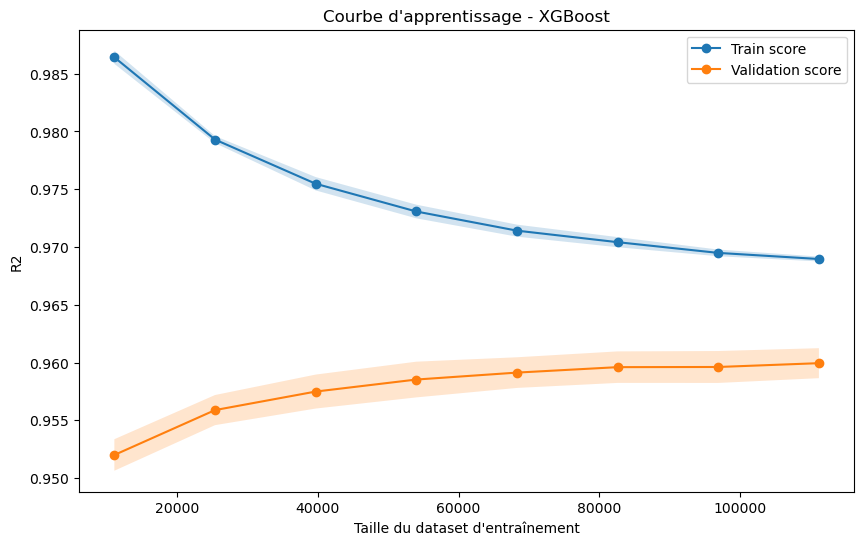

In [17]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Courbe d'apprentissage sur train uniquement
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_train_sel,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Train score', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.plot(train_sizes, test_mean, label='Validation score', marker='o')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2)
plt.title("Courbe d'apprentissage - XGBoost")
plt.xlabel("Taille du dataset d'entraînement")
plt.ylabel('R2')
plt.legend()
plt.show()

## Vérification anti fuite
Le test set n'est utilisé qu'une seule fois pour l'évaluation finale. `nutriscore_score` est uniquement la cible `y` et `nutriscore_grade` n'entre jamais dans `X`. Le modèle n'est pas réentraîné sur tout le dataset dans ce notebook afin d'éviter toute confusion entre entraînement et évaluation.


In [18]:

print('Intersection train/test :', len(set(train_df.index) & set(test_df.index)))
print('\nColonnes utilisées par le modèle :')
print(selected_features)
print('\nLa cible est-elle dans les features ? ', target_col in selected_features)
print('nutriscore_grade est-il dans les features ? ', 'nutriscore_grade' in selected_features)
print('nutriscore_score est-il dans X_test ? ', target_col in X_test.columns)
print('nutriscore_grade est-il dans X_test ? ', 'nutriscore_grade' in X_test.columns)


Intersection train/test : 0

Colonnes utilisées par le modèle :
['energy_100g', 'fat_100g', 'saturated-fat_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'carbohydrates_100g', 'salt_100g', 'non_zero_features', 'total_macro_100g', 'sugar_to_carb_ratio', 'satfat_to_fat_ratio', 'protein_to_energy_ratio', 'fiber_to_carb_ratio']

La cible est-elle dans les features ?  False
nutriscore_grade est-il dans les features ?  False
nutriscore_score est-il dans X_test ?  False
nutriscore_grade est-il dans X_test ?  False


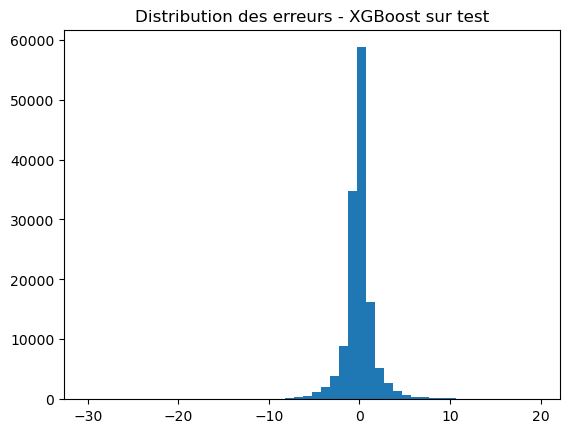

In [19]:
import matplotlib.pyplot as plt

errors = y_test - xgb_pred

plt.hist(errors, bins=50)
plt.title('Distribution des erreurs - XGBoost sur test')
plt.show()


In [20]:
# Conversion du score prédit en Nutri-Score (A, B, C, D, E)

def score_to_grade(score):
    if score <= -1:
        return 'A'
    elif score <= 2:
        return 'B'
    elif score <= 10:
        return 'C'
    elif score <= 18:
        return 'D'
    else:
        return 'E'

# Prédictions du modèle déjà entraîné
pred_score_test = xgb_model.predict(X_test_sel)

# Conversion en lettres
y_pred_grade = pd.Series(pred_score_test).apply(score_to_grade)
y_true_grade = pd.Series(y_test).apply(score_to_grade).reset_index(drop=True)

results_grades = pd.DataFrame({
    'true_score': y_test.reset_index(drop=True),
    'pred_score': pred_score_test,
    'true_grade': y_true_grade,
    'pred_grade': y_pred_grade
})

display(results_grades.head(20))


,true_score,pred_score,true_grade,pred_grade
0,24.0,24.778904,E,E
1,15.0,14.424960,D,D
2,-1.0,-0.267791,A,B
3,31.0,30.942019,E,E
4,8.0,8.005044,C,C
5,1.0,0.094895,B,B
6,23.0,22.501827,E,E
7,7.0,5.174032,C,C
8,-3.0,-0.869466,A,B
9,11.0,11.198779,D,D


## Pas de réentraînement sur tout le dataset
Dans cette version, on s'arrête après l'évaluation sur le split 50/50.
Le modèle n'est pas entraîné sur l'ensemble complet des données nettoyées, afin d'éviter toute confusion avec une prédiction sur des données déjà vues.


In [21]:
# Contrôle final du protocole
print('Le modèle a été entraîné sur X_train uniquement :', X_train.shape)
print('Le modèle a été évalué sur X_test uniquement    :', X_test.shape)
print('Proportion train :', round(len(X_train) / len(training_df), 3))
print('Proportion test  :', round(len(X_test) / len(training_df), 3))


Le modèle a été entraîné sur X_train uniquement : (138982, 14)
Le modèle a été évalué sur X_test uniquement    : (138982, 14)
Proportion train : 0.5
Proportion test  : 0.5


## Analyse des performances du modèle

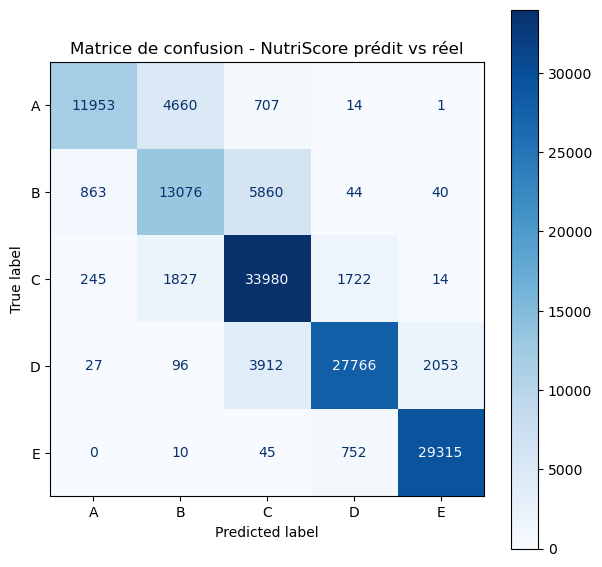

Accuracy NutriScore (A-E) : 0.8353

Classification report :
              precision    recall  f1-score   support

           A       0.91      0.69      0.79     17335
           B       0.66      0.66      0.66     19883
           C       0.76      0.90      0.83     37788
           D       0.92      0.82      0.87     33854
           E       0.93      0.97      0.95     30122

    accuracy                           0.84    138982
   macro avg       0.84      0.81      0.82    138982
weighted avg       0.84      0.84      0.83    138982



In [22]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import matplotlib.pyplot as plt

# Fonction de conversion score -> grade
def score_to_grade(score):
    if score <= -1:
        return "A"
    elif score <= 2:
        return "B"
    elif score <= 10:
        return "C"
    elif score <= 18:
        return "D"
    else:
        return "E"

# Prédictions numériques -> lettres sur le vrai test set uniquement
y_pred_score = xgb_model.predict(X_test_sel)

y_true_grade = pd.Series(y_test).apply(score_to_grade).reset_index(drop=True)
y_pred_grade = pd.Series(y_pred_score).apply(score_to_grade)

labels = ["A", "B", "C", "D", "E"]

# Matrice de confusion
cm = confusion_matrix(y_true_grade, y_pred_grade, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Matrice de confusion - NutriScore prédit vs réel")
plt.show()

# Métriques de classification
acc = accuracy_score(y_true_grade, y_pred_grade)
print(f"Accuracy NutriScore (A-E) : {acc:.4f}\n")

print("Classification report :")
print(classification_report(y_true_grade, y_pred_grade, labels=labels))


In [23]:

# Contrôle de surapprentissage
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Prédictions train / test
train_pred = xgb_model.predict(X_train_sel)
test_pred = xgb_model.predict(X_test_sel)

train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

evaluation_df = pd.DataFrame({
    'Jeu': ['Train', 'Test'],
    'MAE': [train_mae, test_mae],
    'RMSE': [train_rmse, test_rmse],
    'R2': [train_r2, test_r2]
})

display(evaluation_df)

print('Écart Train/Test :')
print(f'Différence MAE  : {abs(train_mae - test_mae):.4f}')
print(f'Différence RMSE : {abs(train_rmse - test_rmse):.4f}')
print(f'Différence R2   : {abs(train_r2 - test_r2):.4f}')

if train_r2 > test_r2 + 0.05:
    print("\nAlerte possible de surapprentissage : le score Train est sensiblement meilleur que le score Test.")
else:
    print("\nPas de signe fort de surapprentissage : les performances Train et Test sont proches.")


SyntaxError: unterminated string literal (detected at line 32) (1006350090.py, line 32)

In [ ]:
# Cross validation sur train uniquement
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

cv_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(cv_model, X_train_sel, y_train, cv=kf, scoring='r2')
cv_rmse = -cross_val_score(cv_model, X_train_sel, y_train, cv=kf, scoring='neg_root_mean_squared_error')

print('Validation croisée 5-fold sur train uniquement')
print(f'R2 moyen   : {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')
print(f'RMSE moyen : {cv_rmse.mean():.4f} +/- {cv_rmse.std():.4f}')